# **Load Dataset**

Link dataset: https://docs.google.com/spreadsheets/d/12JBNbI-e6-3FblLkQfMQmraZzvE1fdEp/edit?usp=sharing&ouid=111980662309612670823&rtpof=true&sd=true

In [1]:
import pandas as pd

# Load dataset
df = pd.read_excel('/content/E_Commerce_Dataset.xlsx', sheet_name='E Comm')

# **Data Cleaning & EDA**

In [2]:
import numpy as np
df.head()

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   object 
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   object 
 7   Gender                       5630 non-null   object 
 8   HourSpendOnApp               5375 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   object 
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null   object 
 13  NumberOfAddress   

In [4]:
df.shape

(5630, 20)

In [5]:
print(df.isnull().sum())

CustomerID                       0
Churn                            0
Tenure                         264
PreferredLoginDevice             0
CityTier                         0
WarehouseToHome                251
PreferredPaymentMode             0
Gender                           0
HourSpendOnApp                 255
NumberOfDeviceRegistered         0
PreferedOrderCat                 0
SatisfactionScore                0
MaritalStatus                    0
NumberOfAddress                  0
Complain                         0
OrderAmountHikeFromlastYear    265
CouponUsed                     256
OrderCount                     258
DaySinceLastOrder              307
CashbackAmount                   0
dtype: int64


In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df['PreferedOrderCat'].value_counts(dropna=False)

,count
PreferedOrderCat,
Laptop & Accessory,2050
Mobile Phone,1271
Fashion,826
Mobile,809
Grocery,410
Others,264


In [8]:
print(df['Churn'].value_counts(normalize=True)*100)

Churn
0    83.161634
1    16.838366
Name: proportion, dtype: float64


In [11]:
# categorical - churn
print(df.groupby('PreferredLoginDevice')['Churn'].mean().sort_values(ascending=False))
print(df.groupby('PreferredPaymentMode')['Churn'].mean().sort_values(ascending=False))
print(df.groupby('Gender')['Churn'].mean().sort_values(ascending=False))
print(df.groupby('PreferedOrderCat')['Churn'].mean().sort_values(ascending=False))
print(df.groupby('MaritalStatus')['Churn'].mean().sort_values(ascending=False))

PreferredLoginDevice
Phone           0.224208
Computer        0.198286
Mobile Phone    0.125859
Name: Churn, dtype: float64
PreferredPaymentMode
COD                 0.287671
E wallet            0.228013
CC                  0.216117
UPI                 0.173913
Cash on Delivery    0.154362
Debit Card          0.153846
Credit Card         0.128581
Name: Churn, dtype: float64
Gender
Male      0.177305
Female    0.154942
Name: Churn, dtype: float64
PreferedOrderCat
Mobile Phone          0.275374
Mobile                0.271941
Fashion               0.154964
Laptop & Accessory    0.102439
Others                0.075758
Grocery               0.048780
Name: Churn, dtype: float64
MaritalStatus
Single      0.267261
Divorced    0.146226
Married     0.115204
Name: Churn, dtype: float64


In [12]:
# numerical - churn
numerical = ['Tenure', 'CityTier', 'WarehouseToHome', 'HourSpendOnApp', 'NumberOfDeviceRegistered', 'SatisfactionScore', 'NumberOfAddress', 'Complain', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount']
print(df[numerical + ['Churn']].corr()['Churn'].drop('Churn').sort_values(key=abs, ascending=False))

Tenure                        -0.349408
Complain                       0.250188
DaySinceLastOrder             -0.160757
CashbackAmount                -0.154118
NumberOfDeviceRegistered       0.107939
SatisfactionScore              0.105481
CityTier                       0.084703
WarehouseToHome                0.076630
NumberOfAddress                0.043931
OrderCount                    -0.028697
HourSpendOnApp                 0.018675
OrderAmountHikeFromlastYear   -0.010058
CouponUsed                    -0.008264
Name: Churn, dtype: float64


# **Feature Engineering**

In [13]:
# drop kolom
df = df.drop(columns=['CustomerID'])

In [16]:
# missing values by median
missing_values = ['Tenure', 'WarehouseToHome', 'HourSpendOnApp', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'DaySinceLastOrder', 'OrderCount']
for col in missing_values:
  df[col] = df[col].fillna(df[col].median())

In [17]:
# one-hot encode
df = pd.get_dummies(df, columns=['PreferredLoginDevice', 'PreferredPaymentMode', 'Gender', 'PreferedOrderCat', 'MaritalStatus'], dtype=int)

**Result**

In [18]:
print(f"Shape: {df.shape}")
print(f"\nColumn:\n{df.columns.tolist()}")
print(f"\nSample:\n{df.head(5).to_string()}")
print(f"\nData Type:\n{df.dtypes}")
print(f"\nMissing Values: {df.isnull().sum().sum()}")

Shape: (5630, 35)

Column:
['Churn', 'Tenure', 'CityTier', 'WarehouseToHome', 'HourSpendOnApp', 'NumberOfDeviceRegistered', 'SatisfactionScore', 'NumberOfAddress', 'Complain', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount', 'PreferredLoginDevice_Computer', 'PreferredLoginDevice_Mobile Phone', 'PreferredLoginDevice_Phone', 'PreferredPaymentMode_CC', 'PreferredPaymentMode_COD', 'PreferredPaymentMode_Cash on Delivery', 'PreferredPaymentMode_Credit Card', 'PreferredPaymentMode_Debit Card', 'PreferredPaymentMode_E wallet', 'PreferredPaymentMode_UPI', 'Gender_Female', 'Gender_Male', 'PreferedOrderCat_Fashion', 'PreferedOrderCat_Grocery', 'PreferedOrderCat_Laptop & Accessory', 'PreferedOrderCat_Mobile', 'PreferedOrderCat_Mobile Phone', 'PreferedOrderCat_Others', 'MaritalStatus_Divorced', 'MaritalStatus_Married', 'MaritalStatus_Single']

Sample:
   Churn  Tenure  CityTier  WarehouseToHome  HourSpendOnApp  NumberOfDeviceRegistered  SatisfactionS

In [20]:
df.to_csv('e_comms_feature.csv', index=False)
print("\n✅ Tersimpan")


✅ Tersimpan


# **Split Data**

In [21]:
from sklearn.model_selection import train_test_split

In [22]:
X = df.drop(columns=['Churn'])
y = df['Churn']

print(X.shape)
print(y.describe())

(5630, 34)
count    5630.000000
mean        0.168384
std         0.374240
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: Churn, dtype: float64


In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
  )

In [24]:
print(f"Train: {X_train.shape}")
print(f"Test: {X_test.shape}")
print(f"Missing train: {X_train.isnull().sum().sum()}")
print(f"Missing test: {X_test.isnull().sum().sum()}")
print(f"Churn rate train: {y_train.mean():.3f}")
print(f"Churn rate test: {y_test.mean():.3f}")

Train: (4504, 34)
Test: (1126, 34)
Missing train: 0
Missing test: 0
Churn rate train: 0.168
Churn rate test: 0.169


# **Train Model**

**Random Forest**

In [34]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix, classification_report,
                             roc_curve, auc)


In [26]:
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',   # penting karena target imbalanced (75% vs 25%)
    random_state=42,
    n_jobs=-1
)

In [27]:
model.fit(X_train, y_train)
y_pred       = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# **Evaluation Model**

In [28]:
print(f"Accuracy : {accuracy_score(y_test, y_pred):.3f}")
print(f"Precision: {precision_score(y_test, y_pred):.3f}")
print(f"Recall   : {recall_score(y_test, y_pred):.3f}")
print(f"F1-score : {f1_score(y_test, y_pred):.3f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_pred_proba):.3f}")

Accuracy : 0.946
Precision: 0.841
Recall   : 0.837
F1-score : 0.839
ROC-AUC  : 0.983


In [29]:
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Confusion Matrix:
[[906  30]
 [ 31 159]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.97      0.97       936
           1       0.84      0.84      0.84       190

    accuracy                           0.95      1126
   macro avg       0.90      0.90      0.90      1126
weighted avg       0.95      0.95      0.95      1126



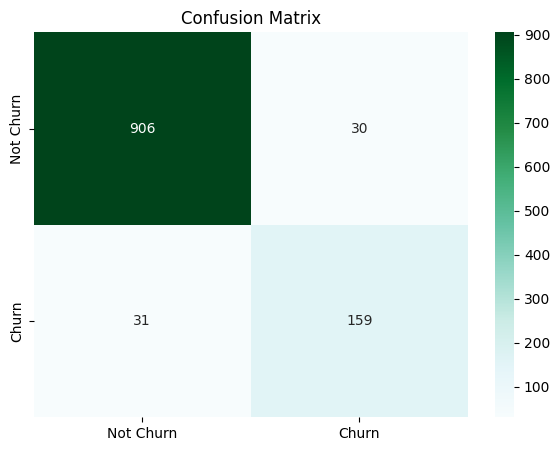

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="BuGn",
            xticklabels=['Not Churn','Churn'], yticklabels=['Not Churn','Churn'])
plt.title("Confusion Matrix")
plt.show()


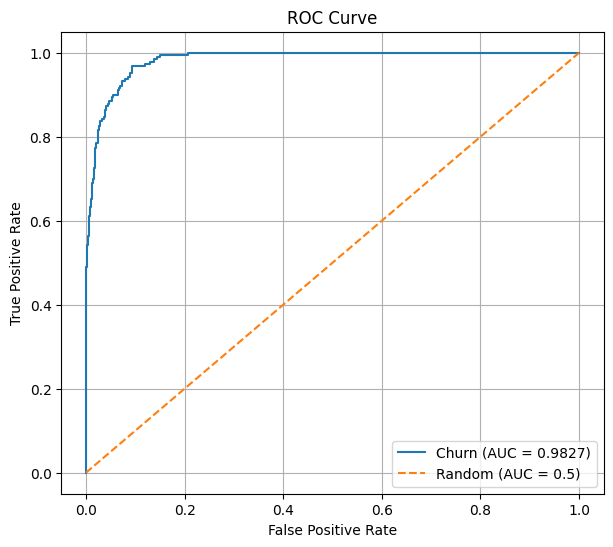

In [35]:
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, label=f'Churn (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], linestyle='--', label='Random (AUC = 0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [40]:
importance = pd.Series(model.feature_importances_, index=X_train.columns)
importance = importance.sort_values(ascending=False)
print("\nTop 10 most important feature:")
print(importance.head(10))


Top 10 most important feature:
Tenure                         0.284416
CashbackAmount                 0.090594
Complain                       0.072277
DaySinceLastOrder              0.060322
WarehouseToHome                0.051663
NumberOfAddress                0.045078
OrderAmountHikeFromlastYear    0.041236
SatisfactionScore              0.039535
NumberOfDeviceRegistered       0.028722
MaritalStatus_Single           0.027336
dtype: float64


# **Inference**

In [39]:
# contoh data customer baru
customer_baru = pd.DataFrame([{
    "Tenure": 1,
    "CityTier": 3,
    "WarehouseToHome": 20,
    "HourSpendOnApp": 2,
    "NumberOfDeviceRegistered": 3,
    "SatisfactionScore": 2,
    "NumberOfAddress": 5,
    "Complain": 4,
    "OrderAmountHikeFromlastYear": 12,
    "CouponUsed": 0,
    "OrderCount": 1,
    "DaySinceLastOrder": 10,
    "CashbackAmount": 50,
    "PreferredLoginDevice_Computer": 0,
    "PreferredLoginDevice_Mobile Phone": 1,
    "PreferredLoginDevice_Phone": 0,
    "PreferredPaymentMode_CC": 0,
    "PreferredPaymentMode_COD": 1,
    "PreferredPaymentMode_Cash on Delivery": 0,
    "PreferredPaymentMode_Credit Card": 0,
    "PreferredPaymentMode_Debit Card": 0,
    "PreferredPaymentMode_E wallet": 0,
    "PreferredPaymentMode_UPI": 0,
    "Gender_Female": 0,
    "Gender_Male": 1,
    "PreferedOrderCat_Fashion": 0,
    "PreferedOrderCat_Grocery": 0,
    "PreferedOrderCat_Laptop & Accessory": 0,
    "PreferedOrderCat_Mobile": 0,
    "PreferedOrderCat_Mobile Phone": 1,
    "PreferedOrderCat_Others": 0,
    "MaritalStatus_Divorced": 0,
    "MaritalStatus_Married": 0,
    "MaritalStatus_Single": 1,
}])

# prediksi
hasil      = model.predict(customer_baru)[0]
probabilitas = model.predict_proba(customer_baru)[0]

print(f"Prediction  : {'CHURN' if hasil == 1 else 'NOT CHURN'}")
print(f"Not Churn Probability : {probabilitas[0]:.2%}")
print(f"Churn Probability     : {probabilitas[1]:.2%}")

Prediction  : CHURN
Not Churn Probability : 42.81%
Churn Probability     : 57.19%


# **Conclusion & Bussiness Interpretaion**

## Technical Performance
The Random Forest model demonstrates strong predictive performance with 94.6% accuracy and a ROC-AUC of 0.983, indicating the model can reliably distinguish between churned and retained customers. Out of 190 actual churn cases in the test set, 159 were correctly identified (Recall 83.7%), with only 31 missed — making it practically viable for real-world early warning systems.

## Bussiness Insight
**Tenure** emerges as the most influential feature (28.4%), confirming that newly joined customers carry the highest churn risk. This suggests the company should prioritize retention efforts in the early months through onboarding programs or new-user incentives. **CashbackAmount** (9.1%) indicates that cashback programs are effective retention tools and worth maintaining. Meanwhile, **Complain** (7.2%) signals that unresolved customer complaints are a strong churn trigger — fast and satisfactory complaint handling is critical.

Overall, this model can be deployed as a churn early warning system, enabling the business to proactively target high-risk customers with personalized retention strategies before they leave.